In [41]:
import math
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML
import numpy

import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm

# !pip install torchvision
import torchvision
import torchinfo

import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms

from torchmetrics.classification import MulticlassAccuracy, MulticlassPrecision, MulticlassRecall, MulticlassF1Score

from numpy.typing import ArrayLike

In [42]:
device = "cuda" if torch.cuda.is_available() else "cpu"

In [81]:
if torch.cuda.is_available():
    print(f"| Usando a GPU: {torch.cuda.get_device_name(0)}")
else:
    print("| Usando a CPU")

| Usando a GPU: NVIDIA GeForce RTX 4060


In [43]:
NUM_EPOCHS = 10

---

### **Funções de plot**

---

In [44]:
def table(data: ArrayLike = None, title: str = "Tabela") -> None:
    if data is None:
        data = np.random.randint(0, 10, size=(5, 5))
    else:
        data = np.asarray(data)

    if data.ndim != 2:
        raise ValueError("O array de entrada precisa ter 2 dimensoes.")

    rows, cols = data.shape

    table_style = "border-collapse: collapse; margin-left: auto; margin-right: auto; text-align: center; font-size: 14px;"
    cell_style = "border: 1px solid #ccc; padding: 6px 12px; text-align: center;"
    header_style = f"{cell_style} font-weight: bold; text-align: center;"

    rows_html = []
    for row in data:
        cells = "".join(f"<td style='{cell_style}'>{val}</td>" for val in row)
        rows_html.append(f"<tr>{cells}</tr>")

    body_html = "\n".join(rows_html)

    html_content = f"""
    <table style='{table_style}'>
        <tr>
            <th colspan='{cols}' style='{header_style}'>{title}</th>
        </tr>
        {body_html}
    </table>
    """

    display(HTML(html_content))

--- 

# Parte A

---

### **01 ) - Análise Exploratória de Dados**

---


**Dataset:**
- Guarda as amostras e seus respectivos rótulos, além de definir como acessar cada item individualmente por um índice.

**DataLoader:**
- Gerencia a entrega dos dados durante o treino, agrupando as amostras em lotes, aplicando o embaralhamento e usando múltiplos processos para acelerar a leitura sem sobrecarregar a memória.

**batch_size:**
- Quantidade de exemplos agrupados para passar juntos pela rede em uma única iteração de cálculo.

**shuffle:**
- Embaralha a ordem das amostras a cada ciclo de treino, evitando que o modelo decore sequências ou crie vícios com base na posição original dos exemplos.

**transforms.ToTensor().:**
- Converte imagens ou matrizes numéricas comuns em tensores do PyTorch, além de reorganizar os eixos para o formato de canais primeiro e normalizar os valores de intensidade dos pixels para o intervalo entre zero e um.

---

##### ***Importando o dataset***


In [45]:
batch_size = 60

train_dataset = datasets.MNIST(root="dataset/", download=True, train=True, transform=transforms.ToTensor())

train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = datasets.MNIST(root="dataset/", download=True, train=False, transform=transforms.ToTensor())

test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=True)

##### ***Quantidade de exemplos de treinamento***


In [46]:
len_test_samples = train_dataset.data.shape[0]

text = f"##### - Quantidade de amostras de treinamento: **{len_test_samples}**"

display(Markdown(text))

##### - Quantidade de amostras de treinamento: **60000**

##### ***Quantidade de exemplos de teste***

In [47]:
len_test_samples = test_dataset.data.shape[0]

text = f"##### - Quantidade de amostras de teste: **{len_test_samples}**"

display(Markdown(text))

##### - Quantidade de amostras de teste: **10000**

##### ***Dimensão das imagens***

In [48]:
imagem, rotulo = train_dataset[0]

text = f"##### - As imagens tem: **{imagem.shape[1]}** dimenções"

display(Markdown(text))

##### - As imagens tem: **28** dimenções

##### ***Número de classes***

In [49]:
text = f"##### - Classes do dataset MNIST:"

display(Markdown(text))

train_dataset.classes

##### - Classes do dataset MNIST:

['0 - zero',
 '1 - one',
 '2 - two',
 '3 - three',
 '4 - four',
 '5 - five',
 '6 - six',
 '7 - seven',
 '8 - eight',
 '9 - nine']

##### ***Tamanho do batch utilizado***

In [50]:
text = f"##### - Tamanho do batch do dataset: **{train_loader.batch_size}**"

display(Markdown(text))

##### - Tamanho do batch do dataset: **60**

##### ***Exemplos de imagens***

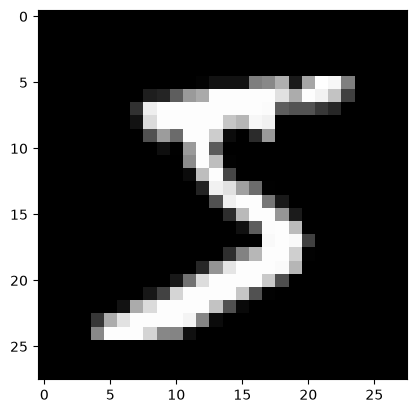

In [51]:
def imshow(img):
   npimg = img.numpy()
   plt.imshow(np.transpose(npimg, (1, 2, 0)))
   plt.show()

dataiter = iter(train_dataset)
images, labels = next(dataiter)

imshow(torchvision.utils.make_grid(images))


---

### **02 ) - Implementação**

---

**Dada a sequência: 1 × 28 × 28 → 8 × 28 × 28 → 8 × 14 × 14 → 16 × 14 × 14 → 16 × 7 × 7 → 784 → 10. Explique por que ocorre cada alteração de dimensionalidade.**

- Partindo da imagem em escala de cinza no formato (1, 28, 28), a primeira convolução gera o mapa (8, 28, 28), que tem sua resolução reduzida para (8, 14, 14) após o pooling. Em seguida, uma segunda convolução amplia os canais para (16, 14, 14) e um novo pooling corta o espaço para (16, 7, 7). Essas matrizes são então reorganizadas em uma lista única de 784 valores, passam por uma camada intermediária de 64 neurônios e chegam à camada final de saída com 10 posições, entregando a pontuação de cada uma das dez classes possíveis.

**Explique também por que operações como ReLU, Max Pooling e Flatten não introduzem parâmetros treináveis.**

- Essas operações não introduzem parâmetros treináveis porque aplicam regras matemáticas fixas e predefinidas, sem nenhum valor ajustável durante o aprendizado da rede.

---

##### ***Arquitetura***

In [52]:
class CNN(nn.Module):
   def __init__(self, in_channels, num_classes):

       super(CNN, self).__init__()

       # 1st convolutional layer
       self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
       # Max pooling layer
       self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
       # 2nd convolutional layer
       self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)
       # Fully connected layer
       self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

   def forward(self, x):

       x = F.relu(self.conv1(x))  
       x = self.pool(x)           
       x = F.relu(self.conv2(x))  
       x = self.pool(x)          
       x = x.reshape(x.shape[0], -1) 
       x = self.fc1(x)           
       return x

In [53]:
model = CNN(in_channels=1, num_classes=10).to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)


##### ***Total de parâmetros***

- Calculei a quantidade correta de parâmetros para cada camada da minha rede convolucional e compilei os resultados na tabela abaixo.

| Camada | Dimensão da entrada | Dimensão da saída | Pesos | Bias | Total de parâmetros |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Conv1 | (1, 28, 28) | (8, 28, 28) | 72 | 8 | 80 |
| Conv2 | (8, 14, 14) | (16, 14, 14) | 1.152 | 16 | 1.168 |
| FC | 784 | 10 | 7.840 | 10 | 7.850 |
| Total | N/A | N/A | 9.064 | 34 | 9.098 |

- Respota final: **9.098** parâmetros. O calculo da quantidade de parâmetros totais bateu com o resultado abaixo obtido pela função de cálculo automático.

In [54]:
text = f"##### | Total de parâmetros: **{sum(p.numel() for p in model.parameters() if p.requires_grad)}**"
display(Markdown(text))

##### | Total de parâmetros: **9098**

---

### **03 ) - Treinamento**

---

##### ***Função de avaliação***

In [55]:
def evaluate_epoch(model, dataloader, criterion, num_classes, device, average="macro"):
    model.eval()
    running_loss = 0.0

    acc_metric = MulticlassAccuracy(num_classes=num_classes, average=average).to(device)
    precision_metric = MulticlassPrecision(num_classes=num_classes, average=average).to(device)
    recall_metric = MulticlassRecall(num_classes=num_classes, average=average).to(device)
    f1_metric = MulticlassF1Score(num_classes=num_classes, average=average).to(device)

    acc_metric.reset()
    precision_metric.reset()
    recall_metric.reset()
    f1_metric.reset()

    with torch.no_grad():
        for data, targets in dataloader:
            data = data.to(device)
            targets = targets.to(device)

            scores = model(data)
            loss = criterion(scores, targets)

            running_loss += loss.item()
            preds = torch.argmax(scores, dim=1)

            acc_metric.update(preds, targets)
            precision_metric.update(preds, targets)
            recall_metric.update(preds, targets)
            f1_metric.update(preds, targets)

    epoch_loss = running_loss / len(dataloader)
    epoch_acc = acc_metric.compute().item()
    epoch_precision = precision_metric.compute().item()
    epoch_recall = recall_metric.compute().item()
    epoch_f1 = f1_metric.compute().item()

    metrics = {
        "loss": epoch_loss,
        "accuracy": epoch_acc,
        "precision": epoch_precision,
        "recall": epoch_recall,
        "f1_score": epoch_f1
    }

    return metrics

##### ***Função de treinamento***

In [56]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs, num_classes, device):

    history = {
        "train_loss": [], "train_acc": [], "train_precision": [], "train_recall": [], "train_f1": [],
        "test_loss": [], "test_acc": [], "test_precision": [], "test_recall": [], "test_f1": [],
        "exec_time": []
    }

    for epoch in range(num_epochs):
        inicio_epoca = time.time()
        
        model.train()
        for data, targets in tqdm(train_loader, desc=f"| Treino Epoca {epoch + 1}/{num_epochs}"):
            data = data.to(device)
            targets = targets.to(device)

            optimizer.zero_grad()
            scores = model(data)
            loss = criterion(scores, targets)
            loss.backward()
            optimizer.step()

        train_metrics = evaluate_epoch(
            model=model,
            dataloader=train_loader,
            criterion=criterion,
            num_classes=num_classes,
            device=device
        )
        test_metrics = evaluate_epoch(
            model=model,
            dataloader=test_loader,
            criterion=criterion,
            num_classes=num_classes,
            device=device
        )

        tempo_decorrido = time.time() - inicio_epoca

        history["train_loss"].append(train_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["train_precision"].append(train_metrics["precision"])
        history["train_recall"].append(train_metrics["recall"])
        history["train_f1"].append(train_metrics["f1_score"])

        history["test_loss"].append(test_metrics["loss"])
        history["test_acc"].append(test_metrics["accuracy"])
        history["test_precision"].append(test_metrics["precision"])
        history["test_recall"].append(test_metrics["recall"])
        history["test_f1"].append(test_metrics["f1_score"])

        history["exec_time"].append(tempo_decorrido)

        print(
            f"| Epoca [{epoch + 1}/{num_epochs}] | Tempo: {tempo_decorrido:.2f}s\n"
            f"  Treino -> Loss: {train_metrics['loss']:.4f} | Acc: {train_metrics['accuracy']:.4f} | "
            f"Prec: {train_metrics['precision']:.4f} | Rec: {train_metrics['recall']:.4f} | F1: {train_metrics['f1_score']:.4f}\n"
            f"  Teste  -> Loss: {test_metrics['loss']:.4f} | Acc: {test_metrics['accuracy']:.4f} | "
            f"Prec: {test_metrics['precision']:.4f} | Rec: {test_metrics['recall']:.4f} | F1: {test_metrics['f1_score']:.4f}\n"
        )

    return history

##### ***Treinamento***

In [57]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [58]:
history_model = train_model(
    model=model,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
    num_classes=10,
    device=device
)

| Treino Epoca 1/10: 100%|██████████| 1000/1000 [00:04<00:00, 215.63it/s]


| Epoca [1/10] | Tempo: 10.73s
  Treino -> Loss: 0.1369 | Acc: 0.9594 | Prec: 0.9597 | Rec: 0.9594 | F1: 0.9591
  Teste  -> Loss: 0.1301 | Acc: 0.9600 | Prec: 0.9603 | Rec: 0.9600 | F1: 0.9598



| Treino Epoca 2/10: 100%|██████████| 1000/1000 [00:04<00:00, 208.89it/s]


| Epoca [2/10] | Tempo: 10.89s
  Treino -> Loss: 0.1124 | Acc: 0.9619 | Prec: 0.9646 | Rec: 0.9619 | F1: 0.9623
  Teste  -> Loss: 0.1094 | Acc: 0.9609 | Prec: 0.9639 | Rec: 0.9609 | F1: 0.9614



| Treino Epoca 3/10: 100%|██████████| 1000/1000 [00:04<00:00, 213.58it/s]


...

| Epoca [8/10] | Tempo: 11.24s
  Treino -> Loss: 0.0454 | Acc: 0.9853 | Prec: 0.9854 | Rec: 0.9853 | F1: 0.9852
  Teste  -> Loss: 0.0649 | Acc: 0.9789 | Prec: 0.9792 | Rec: 0.9789 | F1: 0.9789



| Treino Epoca 9/10: 100%|██████████| 1000/1000 [00:04<00:00, 211.83it/s]


| Epoca [9/10] | Tempo: 10.77s
  Treino -> Loss: 0.0310 | Acc: 0.9899 | Prec: 0.9899 | Rec: 0.9899 | F1: 0.9899
  Teste  -> Loss: 0.0443 | Acc: 0.9848 | Prec: 0.9847 | Rec: 0.9848 | F1: 0.9848



| Treino Epoca 10/10: 100%|██████████| 1000/1000 [00:05<00:00, 193.45it/s]


| Epoca [10/10] | Tempo: 11.24s
  Treino -> Loss: 0.0297 | Acc: 0.9902 | Prec: 0.9904 | Rec: 0.9902 | F1: 0.9903
  Teste  -> Loss: 0.0428 | Acc: 0.9853 | Prec: 0.9856 | Rec: 0.9853 | F1: 0.9854



##### ***Avaliação***

In [59]:
input_data = np.array([
    ["Conjunto", "Metrica", "Valor"],
    ["Teste", "Acuracia", f"{history_model['test_acc'][-1]:.4f}"],
    ["Teste", "Loss", f"{history_model['test_loss'][-1]:.4f}"],
    ["Teste", "Precisao", f"{history_model['test_precision'][-1]:.4f}"],
    ["Teste", "Recall", f"{history_model['test_recall'][-1]:.4f}"],
    ["Teste", "F1-Score", f"{history_model['test_f1'][-1]:.4f}"],
    ["Geral", "Tempo total (s)", f"{np.sum(history_model['exec_time']):.2f}"]
])

table(title="Modelo base - (CNN)", data=input_data)

--- 

# Parte B

---

### **B1 ) - (CNN, Batch Normalization)**

---

**Qual é a finalidade da Batch Normalization.**

- Padroniza as entradas de cada camada para que tenham média zero e variância unitária dentro de cada mini-lote. Dessa forma, evitando que as camadas precisem se adaptar constantemente a diferentes distribuições dos dados.

**Quais parâmetros são aprendidos pela camada.**

- A camada de normalização de lotes aprende dois parâmetros fundamentais chamados gama e beta, que atuam respectivamente como fatores de escala e deslocamento. Inicialmente, a camada padroniza as ativações para que tenham média zero e variabilidade unitária, mas esse formato rígido nem sempre é o ideal para o aprendizado da rede. É aí que esses dois parâmetros entram em ação: eles permitem que o próprio modelo ajuste a amplitude e a posição dos dados normalizados, restaurando a capacidade expressiva das camadas seguintes caso a distribuição inicial limite o desempenho.

**Por que seu comportamento é diferente durante treinamento e inferência.**

- O comportamento dessa camada muda entre treino e inferência para garantir estabilidade e previsibilidade. Durante o treinamento, a média e a variabilidade são calculadas em tempo real com base apenas nos exemplos presentes no lote atual, enquanto o modelo mantém uma estimativa móvel e acumulada dessas estatísticas para todo o conjunto de dados. Já na fase de inferência, como a rede costuma receber apenas uma amostra por vez e precisa produzir resultados consistentes, o cálculo por lote é desligado e o modelo passa a usar os valores médios fixos acumulados durante o treino.

---

##### ***Arquitetura do Modelo BN - (CNN, Batch Normalization)***

In [60]:
class CNN_BN(nn.Module):
    def __init__(self, in_channels: int = 1, num_classes: int = 10):
        super(CNN_BN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(num_features=8)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(num_features=16)

        self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

    def forward(self, x):
        # Bloco A - Convolução -> BatchNorm -> Ativação -> Pooling
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)

        # Bloco B - Convolução -> BatchNorm -> Ativação -> Pooling
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)

        # Achatamento
        x = torch.flatten(x, 1)
        
        # Camada de classificação
        x = self.fc1(x)

        return x

model_bn = CNN_BN(in_channels=1, num_classes=10).to(device)
print(model_bn)

CNN_BN(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)


##### ***Treinamento do Modelo BN - (CNN, Batch Normalization)***

In [61]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_bn.parameters(), lr=0.001)

In [62]:
history_model_bn = train_model(
    model=model_bn,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
    num_classes=10,
    device=device
)

| Treino Epoca 1/10: 100%|██████████| 1000/1000 [00:04<00:00, 200.61it/s]


| Epoca [1/10] | Tempo: 11.30s
  Treino -> Loss: 0.0687 | Acc: 0.9792 | Prec: 0.9792 | Rec: 0.9792 | F1: 0.9791
  Teste  -> Loss: 0.0653 | Acc: 0.9795 | Prec: 0.9797 | Rec: 0.9795 | F1: 0.9794



| Treino Epoca 2/10: 100%|██████████| 1000/1000 [00:04<00:00, 207.98it/s]


| Epoca [2/10] | Tempo: 10.92s
  Treino -> Loss: 0.0493 | Acc: 0.9847 | Prec: 0.9848 | Rec: 0.9847 | F1: 0.9847
  Teste  -> Loss: 0.0547 | Acc: 0.9830 | Prec: 0.9832 | Rec: 0.9830 | F1: 0.9831



| Treino Epoca 3/10: 100%|██████████| 1000/1000 [00:04<00:00, 204.53it/s]


...

| Epoca [8/10] | Tempo: 12.03s
  Treino -> Loss: 0.0179 | Acc: 0.9948 | Prec: 0.9949 | Rec: 0.9948 | F1: 0.9949
  Teste  -> Loss: 0.0403 | Acc: 0.9865 | Prec: 0.9867 | Rec: 0.9865 | F1: 0.9866



| Treino Epoca 9/10: 100%|██████████| 1000/1000 [00:05<00:00, 188.46it/s]


| Epoca [9/10] | Tempo: 11.85s
  Treino -> Loss: 0.0228 | Acc: 0.9921 | Prec: 0.9920 | Rec: 0.9921 | F1: 0.9920
  Teste  -> Loss: 0.0512 | Acc: 0.9849 | Prec: 0.9848 | Rec: 0.9849 | F1: 0.9847



| Treino Epoca 10/10: 100%|██████████| 1000/1000 [00:05<00:00, 188.95it/s]


| Epoca [10/10] | Tempo: 11.91s
  Treino -> Loss: 0.0144 | Acc: 0.9955 | Prec: 0.9956 | Rec: 0.9955 | F1: 0.9955
  Teste  -> Loss: 0.0465 | Acc: 0.9867 | Prec: 0.9868 | Rec: 0.9867 | F1: 0.9867



##### ***Avaliação do Modelo BN - (CNN, Batch Normalization)***

In [63]:
input_data_bn = np.array([
    ["Conjunto", "Metrica", "Valor"],
    ["Teste", "Acuracia", f"{history_model_bn['test_acc'][-1]:.4f}"],
    ["Teste", "Loss", f"{history_model_bn['test_loss'][-1]:.4f}"],
    ["Teste", "Precisao", f"{history_model_bn['test_precision'][-1]:.4f}"],
    ["Teste", "Recall", f"{history_model_bn['test_recall'][-1]:.4f}"],
    ["Teste", "F1-Score", f"{history_model_bn['test_f1'][-1]:.4f}"],
    ["Geral", "Tempo total (s)", f"{np.sum(history_model_bn['exec_time']):.2f}"]
])

table(title="Modelo BN - (CNN, Batch Normalization)", data=input_data_bn)

---

### **B2 ) - (CNN, Weight Initializer)**

---


**por que a inicialização dos pesos é importante.**

- A inicialização correta dos pesos é fundamental para quebrar a simetria entre os neurônios da rede, impedindo que todos aprendam exatamente as mesmas características e atuem de forma redundante. Quando os pesos começam com valores distintos e bem calibrados, cada neurônio consegue se especializar em padrões diferentes desde o primeiro ciclo de treino.

**o problema de inicializações inadequadas.**

- Uma inicialização inadequada pode provocar a simetria de aprendizado entre os neurônios, fazendo com que unidades da mesma camada calculem as mesmas respostas e recebam as mesmas correções, o que impede a extração de características visuais distintas e torna a rede redundante.

- Além disso, pesos mal calibrados desestabilizam o fluxo de informações ao longo das camadas profundas. Se os valores iniciais forem muito pequenos, os sinais de atualização diminuem sucessivamente até desaparecerem no problema conhecido como gradiente evanescente, enquanto valores iniciais excessivamente altos causam a explosão desses sinais, inviabilizando a convergência do modelo.

**a relação entre Kaiming/He Initialization e a função ReLU.**

- A ReLU desativa metade dos neurônios ao transformar todas as entradas negativas em zero, o que corta a intensidade dos sinais pela metade a cada camada percorrida na rede. Métodos tradicionais de inicialização não previam essa perda drástica, fazendo com que os sinais encolhessem até desaparecerem em modelos profundos.

- A inicialização Kaiming corrige essa queda ao dobrar a escala da variância dos pesos sorteados, compensando exatamente os cinquenta por cento das ativações anuladas pela ReLU. Esse ajuste mantém a energia das informações estável da primeira à última camada, garantindo um treinamento rápido e sem desaparecimento de gradientes.

---

##### ***Arquitetura do Modelo WI - (CNN, Weight Initializer)***

In [64]:
class CNN_WI(nn.Module):
    def __init__(self, in_channels: int = 1, num_classes: int = 10):
        super(CNN_WI, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)

        self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

        # Aplicação da inicialização de pesos
        self.apply(self.weight_initializer)

    def forward(self, x):
        # Bloco A - Convolução -> Ativação -> Pooling
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        # Bloco B - Convolução -> Ativação -> Pooling
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        # Achatamento
        x = torch.flatten(x, 1)

        # Camada de classificação
        x = self.fc1(x)

        return x

    @staticmethod
    def weight_initializer(modulo):
        if isinstance(modulo, (nn.Conv2d, nn.Linear)):
            nn.init.kaiming_normal_(modulo.weight, mode='fan_in', nonlinearity='relu')
            if modulo.bias is not None:
                nn.init.zeros_(modulo.bias)

model_wi = CNN_WI(in_channels=1, num_classes=10).to(device)
print(model_wi)

CNN_WI(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)


##### ***Treinamento do Modelo WI - (CNN, Weight Initializer)***

In [65]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_wi.parameters(), lr=0.001)

In [66]:
history_model_wi = train_model(
    model=model_wi,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
    num_classes=10,
    device=device
)

| Treino Epoca 1/10: 100%|██████████| 1000/1000 [00:05<00:00, 192.45it/s]


| Epoca [1/10] | Tempo: 11.75s
  Treino -> Loss: 0.1031 | Acc: 0.9694 | Prec: 0.9695 | Rec: 0.9694 | F1: 0.9693
  Teste  -> Loss: 0.0939 | Acc: 0.9710 | Prec: 0.9709 | Rec: 0.9710 | F1: 0.9708



| Treino Epoca 2/10: 100%|██████████| 1000/1000 [00:05<00:00, 191.71it/s]


| Epoca [2/10] | Tempo: 11.85s
  Treino -> Loss: 0.0648 | Acc: 0.9805 | Prec: 0.9807 | Rec: 0.9805 | F1: 0.9806
  Teste  -> Loss: 0.0622 | Acc: 0.9784 | Prec: 0.9787 | Rec: 0.9784 | F1: 0.9785



| Treino Epoca 3/10: 100%|██████████| 1000/1000 [00:05<00:00, 190.30it/s]


...

| Epoca [8/10] | Tempo: 11.03s
  Treino -> Loss: 0.0259 | Acc: 0.9921 | Prec: 0.9922 | Rec: 0.9921 | F1: 0.9921
  Teste  -> Loss: 0.0382 | Acc: 0.9865 | Prec: 0.9865 | Rec: 0.9865 | F1: 0.9865



| Treino Epoca 9/10: 100%|██████████| 1000/1000 [00:04<00:00, 201.60it/s]


| Epoca [9/10] | Tempo: 11.46s
  Treino -> Loss: 0.0275 | Acc: 0.9915 | Prec: 0.9914 | Rec: 0.9915 | F1: 0.9914
  Teste  -> Loss: 0.0431 | Acc: 0.9856 | Prec: 0.9857 | Rec: 0.9856 | F1: 0.9856



| Treino Epoca 10/10: 100%|██████████| 1000/1000 [00:04<00:00, 205.08it/s]


| Epoca [10/10] | Tempo: 10.90s
  Treino -> Loss: 0.0208 | Acc: 0.9937 | Prec: 0.9938 | Rec: 0.9937 | F1: 0.9938
  Teste  -> Loss: 0.0365 | Acc: 0.9879 | Prec: 0.9881 | Rec: 0.9879 | F1: 0.9880



##### ***Avaliação do Modelo WI - (CNN, Weight Initializer)***

In [67]:
input_data_wi = np.array([
    ["Conjunto", "Metrica", "Valor"],
    ["Teste", "Acuracia", f"{history_model_wi['test_acc'][-1]:.4f}"],
    ["Teste", "Loss", f"{history_model_wi['test_loss'][-1]:.4f}"],
    ["Teste", "Precisao", f"{history_model_wi['test_precision'][-1]:.4f}"],
    ["Teste", "Recall", f"{history_model_wi['test_recall'][-1]:.4f}"],
    ["Teste", "F1-Score", f"{history_model_wi['test_f1'][-1]:.4f}"],
    ["Geral", "Tempo total (s)", f"{np.sum(history_model_wi['exec_time']):.2f}"]
])

table(title="Modelo WI - (CNN, Weight Initializer)", data=input_data_wi)

---

### **B3 ) - (CNN, Dropout)**

---

**Como o Dropout funciona.**

- O Dropout atua desativando aleatoriamente uma porcentagem predefinida de neurônios a cada passagem de um novo lote de dados durante o treinamento. Essa seleção muda continuamente a cada iteração, fazendo com que a rede treine com subconjuntos diferentes de neurônios a cada passo e precise aprender a resolver a tarefa sem contar sempre com os mesmos caminhos.

**Por que ele pode reduzir overfitting.**

- Ao desligar unidades de forma imprevisível, a técnica impede a chamada coadaptação, uma situação em que certos neurônios passam a depender excessivamente da presença de outros para corrigir seus próprios erros. Essa independência forçada distribui a representação do conhecimento por toda a arquitetura, evitando a hiperespecialização em detalhes ruidosos do conjunto de treino e gerando uma capacidade de generalização muito mais robusta para exemplos inéditos.

**O que ocorre com a camada durante model.train() e model.eval().**

- No modo de treinamento ativado por model.train(), a camada opera ativamente sorteando e zerando as conexões de acordo com a probabilidade estipulada, além de reescalar as ativações restantes para compensar a perda de intensidade. Já no modo de avaliação ativado por model.eval(), o Dropout é completamente desligado para permitir que todos os neurônios permaneçam ativos, garantindo que a rede funcione com sua capacidade total e gere previsões determinísticas e consistentes a cada inferência.

---

##### ***Arquitetura do Modelo DP - (CNN, Dropout)***

In [68]:
class CNN_DP(nn.Module):
    def __init__(self, in_channels: int = 1, num_classes: int = 10, dropout_rate: float = 0.25):
        super(CNN_DP, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1)

        self.dropout = nn.Dropout(p=dropout_rate)

        self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

    def forward(self, x):
        # Bloco A - Convolução -> Ativação -> Pooling
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        # Bloco B - Convolução -> Ativação -> Pooling
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        # Achatamento
        x = torch.flatten(x, 1)

        # Aplicação do Dropout
        x = self.dropout(x)

        # Camada de classificação
        x = self.fc1(x)

        return x

model_dp = CNN_DP(in_channels=1, num_classes=10, dropout_rate=0.25).to(device)
print(model_dp)

CNN_DP(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)


In [69]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_dp.parameters(), lr=0.001)

In [70]:
history_model_dp = train_model(
    model=model_dp,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
    num_classes=10,
    device=device
)

| Treino Epoca 1/10: 100%|██████████| 1000/1000 [00:04<00:00, 207.91it/s]


| Epoca [1/10] | Tempo: 10.87s
  Treino -> Loss: 0.1229 | Acc: 0.9632 | Prec: 0.9641 | Rec: 0.9632 | F1: 0.9634
  Teste  -> Loss: 0.1111 | Acc: 0.9660 | Prec: 0.9668 | Rec: 0.9660 | F1: 0.9663



| Treino Epoca 2/10: 100%|██████████| 1000/1000 [00:04<00:00, 219.59it/s]


| Epoca [2/10] | Tempo: 10.82s
  Treino -> Loss: 0.0783 | Acc: 0.9763 | Prec: 0.9764 | Rec: 0.9763 | F1: 0.9763
  Teste  -> Loss: 0.0696 | Acc: 0.9785 | Prec: 0.9785 | Rec: 0.9785 | F1: 0.9784



| Treino Epoca 3/10: 100%|██████████| 1000/1000 [00:04<00:00, 202.57it/s]


...

| Epoca [8/10] | Tempo: 10.85s
  Treino -> Loss: 0.0369 | Acc: 0.9892 | Prec: 0.9891 | Rec: 0.9892 | F1: 0.9891
  Teste  -> Loss: 0.0445 | Acc: 0.9860 | Prec: 0.9859 | Rec: 0.9860 | F1: 0.9859



| Treino Epoca 9/10: 100%|██████████| 1000/1000 [00:04<00:00, 201.52it/s]


| Epoca [9/10] | Tempo: 11.23s
  Treino -> Loss: 0.0331 | Acc: 0.9901 | Prec: 0.9902 | Rec: 0.9901 | F1: 0.9902
  Teste  -> Loss: 0.0389 | Acc: 0.9861 | Prec: 0.9863 | Rec: 0.9861 | F1: 0.9862



| Treino Epoca 10/10: 100%|██████████| 1000/1000 [00:04<00:00, 206.81it/s]


| Epoca [10/10] | Tempo: 11.02s
  Treino -> Loss: 0.0308 | Acc: 0.9904 | Prec: 0.9905 | Rec: 0.9904 | F1: 0.9904
  Teste  -> Loss: 0.0393 | Acc: 0.9859 | Prec: 0.9861 | Rec: 0.9859 | F1: 0.9859



In [71]:
input_data_dp = np.array([
    ["Conjunto", "Metrica", "Valor"],
    ["Teste", "Acuracia", f"{history_model_dp['test_acc'][-1]:.4f}"],
    ["Teste", "Loss", f"{history_model_dp['test_loss'][-1]:.4f}"],
    ["Teste", "Precisao", f"{history_model_dp['test_precision'][-1]:.4f}"],
    ["Teste", "Recall", f"{history_model_dp['test_recall'][-1]:.4f}"],
    ["Teste", "F1-Score", f"{history_model_dp['test_f1'][-1]:.4f}"],
    ["Geral", "Tempo total (s)", f"{np.sum(history_model_dp['exec_time']):.2f}"]
])

table(title="Modelo DP - (CNN, Dropout)", data=input_data_dp)

--- 

# Parte C

---

### **C1 ) - (CNN, Batch Normalization, Weight Initializer, Dropout)**

---

##### ***Arquitetura do Modelo Complete - (CNN, Batch Normalization, Weight Initializer, Dropout)***

In [72]:
class CNN_COMPLETE(nn.Module):
    def __init__(self, in_channels: int = 1, num_classes: int = 10, dropout_rate: float = 0.25):
        super(CNN_COMPLETE, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=in_channels, out_channels=8, kernel_size=3, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(num_features=8)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)
        
        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(num_features=16)

        self.dropout = nn.Dropout(p=dropout_rate)

        self.fc1 = nn.Linear(16 * 7 * 7, num_classes)

        # Aplicação da inicialização de pesos
        self.apply(self.weight_initializer)

    def forward(self, x):
        # Bloco A - Convolução -> Batch Normalization -> Ativação -> Pooling
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.pool(x)

        # Bloco B - Convolução -> Batch Normalization -> Ativação -> Pooling
        x = self.conv2(x)
        x = self.bn2(x)
        x = F.relu(x)
        x = self.pool(x)

        # Achatamento
        x = torch.flatten(x, 1)

        # Aplicação do Dropout
        x = self.dropout(x)

        # Camada de classificação
        x = self.fc1(x)

        return x

    @staticmethod
    def weight_initializer(modulo):
        if isinstance(modulo, (nn.Conv2d, nn.Linear)):
            nn.init.kaiming_normal_(modulo.weight, mode='fan_in', nonlinearity='relu')
            if modulo.bias is not None:
                nn.init.zeros_(modulo.bias)

model_complete = CNN_COMPLETE(in_channels=1, num_classes=10).to(device)
print(model_complete)

CNN_COMPLETE(
  (conv1): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn1): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
  (bn2): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (dropout): Dropout(p=0.25, inplace=False)
  (fc1): Linear(in_features=784, out_features=10, bias=True)
)


##### ***Treinamento do Modelo Complete - (CNN, Batch Normalization, Weight Initializer, Dropout)***

In [73]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_complete.parameters(), lr=0.001)

In [74]:
history_model_complete = train_model(
    model=model_complete,
    train_loader=train_loader,
    test_loader=test_loader,
    criterion=criterion,
    optimizer=optimizer,
    num_epochs=NUM_EPOCHS,
    num_classes=10,
    device=device
)

| Treino Epoca 1/10: 100%|██████████| 1000/1000 [00:05<00:00, 197.68it/s]


| Epoca [1/10] | Tempo: 11.46s
  Treino -> Loss: 0.0910 | Acc: 0.9738 | Prec: 0.9740 | Rec: 0.9738 | F1: 0.9739
  Teste  -> Loss: 0.0912 | Acc: 0.9728 | Prec: 0.9730 | Rec: 0.9728 | F1: 0.9728



| Treino Epoca 2/10: 100%|██████████| 1000/1000 [00:04<00:00, 202.64it/s]


| Epoca [2/10] | Tempo: 11.05s
  Treino -> Loss: 0.0649 | Acc: 0.9803 | Prec: 0.9801 | Rec: 0.9803 | F1: 0.9802
  Teste  -> Loss: 0.0627 | Acc: 0.9804 | Prec: 0.9803 | Rec: 0.9804 | F1: 0.9803



| Treino Epoca 3/10: 100%|██████████| 1000/1000 [00:04<00:00, 203.06it/s]


...

| Epoca [8/10] | Tempo: 11.51s
  Treino -> Loss: 0.0327 | Acc: 0.9895 | Prec: 0.9895 | Rec: 0.9895 | F1: 0.9894
  Teste  -> Loss: 0.0404 | Acc: 0.9867 | Prec: 0.9867 | Rec: 0.9867 | F1: 0.9867



| Treino Epoca 9/10: 100%|██████████| 1000/1000 [00:05<00:00, 196.51it/s]


| Epoca [9/10] | Tempo: 11.58s
  Treino -> Loss: 0.0292 | Acc: 0.9908 | Prec: 0.9910 | Rec: 0.9908 | F1: 0.9909
  Teste  -> Loss: 0.0388 | Acc: 0.9865 | Prec: 0.9868 | Rec: 0.9865 | F1: 0.9866



| Treino Epoca 10/10: 100%|██████████| 1000/1000 [00:05<00:00, 197.92it/s]


| Epoca [10/10] | Tempo: 11.58s
  Treino -> Loss: 0.0264 | Acc: 0.9918 | Prec: 0.9917 | Rec: 0.9918 | F1: 0.9918
  Teste  -> Loss: 0.0365 | Acc: 0.9880 | Prec: 0.9881 | Rec: 0.9880 | F1: 0.9881



##### ***Avaliação do Modelo Complete - (CNN, Batch Normalization, Weight Initializer, Dropout)***

In [75]:
input_data_complete = np.array([
    ["Conjunto", "Metrica", "Valor"],
    ["Teste", "Acuracia", f"{history_model_complete['test_acc'][-1]:.4f}"],
    ["Teste", "Loss", f"{history_model_complete['test_loss'][-1]:.4f}"],
    ["Teste", "Precisao", f"{history_model_complete['test_precision'][-1]:.4f}"],
    ["Teste", "Recall", f"{history_model_complete['test_recall'][-1]:.4f}"],
    ["Teste", "F1-Score", f"{history_model_complete['test_f1'][-1]:.4f}"],
    ["Geral", "Tempo total (s)", f"{np.sum(history_model_complete['exec_time']):.2f}"]
])

table(title="Modelo Completo", data=input_data_complete)

---

### **C2 ) - Comparação entre todos os modelos**

---

In [76]:
models_info = [
    ("(CNN)", model, history_model),
    ("(CNN, BN)", model_bn, history_model_bn),
    ("(CNN, WI)", model_wi, history_model_wi),
    ("(CNN, DP)", model_dp, history_model_dp),
    ("CNN Complete", model_complete, history_model_complete),
]

header = ["Modelo", "Nº de Parametros", "Acuracia Treino", "Acuracia Teste", "Loss Treino", "Tempo Total"]

rows = [
    [
        name,
        f"{sum(p.numel() for p in m.parameters())}",
        f"{h['train_acc'][-1]:.4f}",
        f"{h['test_acc'][-1]:.4f}",
        f"{h['train_loss'][-1]:.4f}",
        f"{np.sum(h['exec_time']):.2f}s"
    ]
    for name, m, h in models_info
]

table(title="COMPARAÇÃO FINAL", data=np.array([header] + rows))

---

### **C3 ) - Gráficos finais**

---

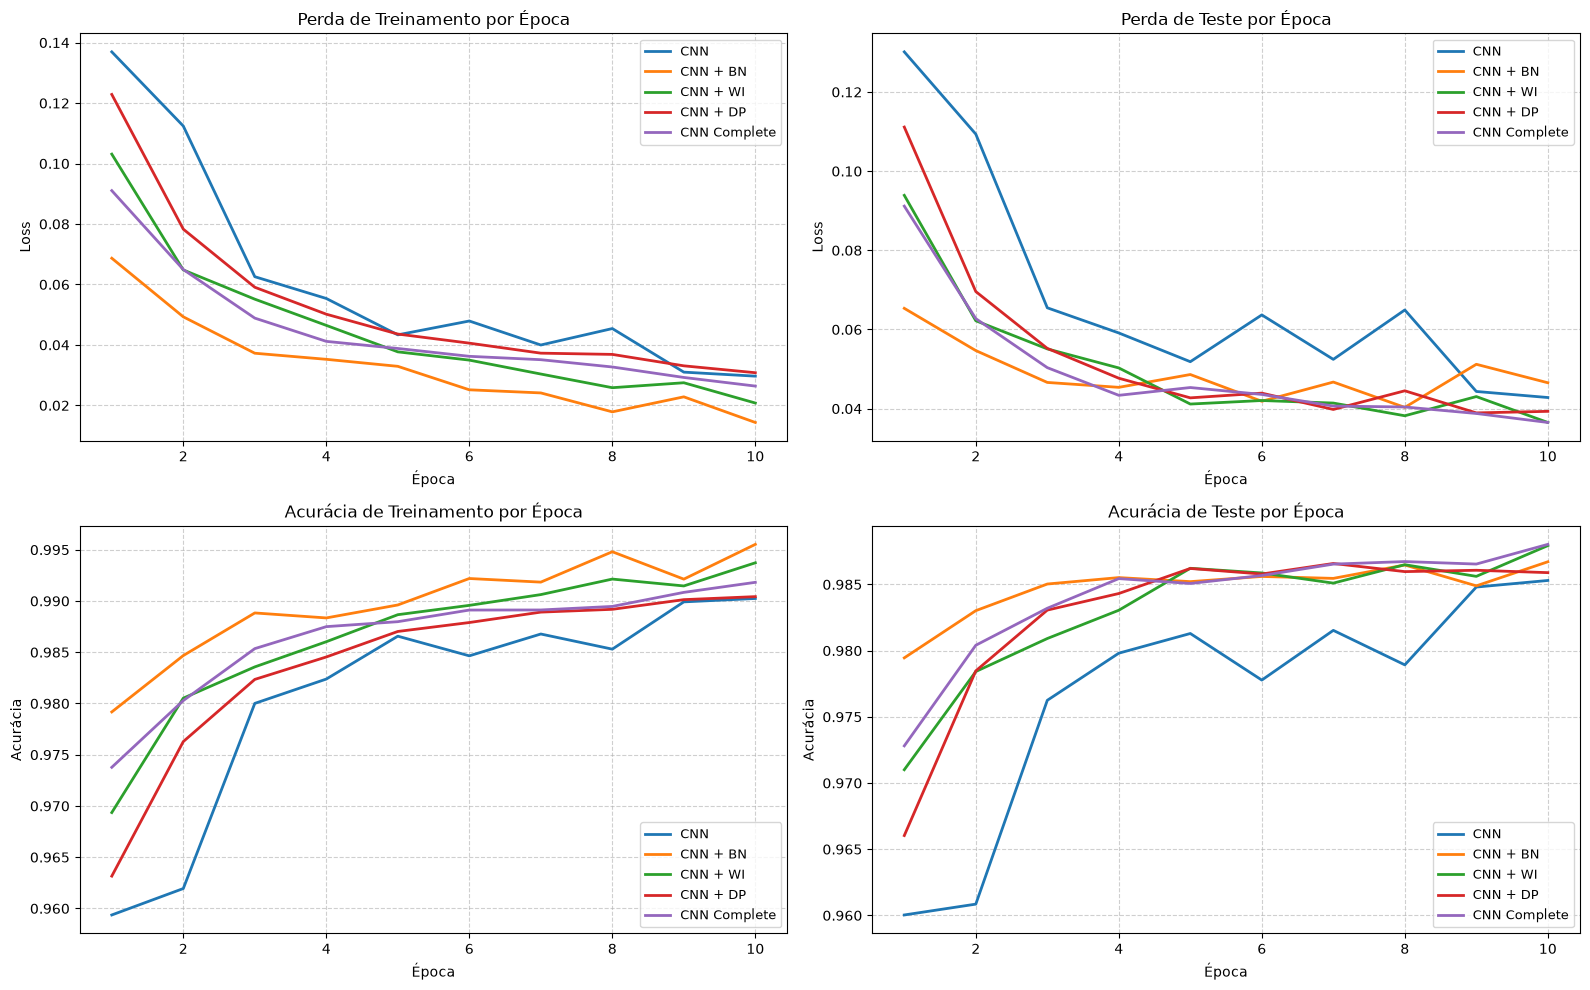

In [77]:
def plot_training_comparison(historicos):
    config = [
        ("train_loss", "Perda de Treinamento", "Loss"),
        ("test_loss", "Perda de Teste", "Loss"),
        ("train_acc", "Acurácia de Treinamento", "Acurácia"),
        ("test_acc", "Acurácia de Teste", "Acurácia")
    ]
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    
    for ax, (metrica, titulo, y_label) in zip(axes.flatten(), config):
        for nome, hist in historicos.items():
            epocas = range(1, len(hist[metrica]) + 1)
            ax.plot(epocas, hist[metrica], label=nome, linewidth=2)
            
        ax.set_title(f"{titulo} por Época", fontsize=12)
        ax.set_xlabel("Época", fontsize=10)
        ax.set_ylabel(y_label, fontsize=10)
        ax.grid(True, linestyle="--", alpha=0.6)
        ax.legend(fontsize=9)
        
    plt.tight_layout()
    plt.show()

# Chamada da função
plot_training_comparison({
    "CNN": history_model,
    "CNN + BN": history_model_bn,
    "CNN + WI": history_model_wi,
    "CNN + DP": history_model_dp,
    "CNN Complete": history_model_complete
})

--- 

# Parte D

In [78]:
torchinfo.summary(model)

Layer (type:depth-idx)                   Param #
CNN                                      --
├─Conv2d: 1-1                            80
├─MaxPool2d: 1-2                         --
├─Conv2d: 1-3                            1,168
├─Linear: 1-4                            7,850
Total params: 9,098
Trainable params: 9,098
Non-trainable params: 0

In [79]:
torchinfo.summary(model_bn)

Layer (type:depth-idx)                   Param #
CNN_BN                                   --
├─Conv2d: 1-1                            72
├─BatchNorm2d: 1-2                       16
├─MaxPool2d: 1-3                         --
├─Conv2d: 1-4                            1,152
├─BatchNorm2d: 1-5                       32
├─Linear: 1-6                            7,850
Total params: 9,122
Trainable params: 9,122
Non-trainable params: 0

In [80]:
torchinfo.summary(model_wi)

Layer (type:depth-idx)                   Param #
CNN_WI                                   --
├─Conv2d: 1-1                            80
├─MaxPool2d: 1-2                         --
├─Conv2d: 1-3                            1,168
├─Linear: 1-4                            7,850
Total params: 9,098
Trainable params: 9,098
Non-trainable params: 0

---

### **D1 ) - Perguntas**

---

**1. Qual foi o número total de parâmetros treináveis da CNN original?**

- A CNN original teve 9098 parâmetros finais.

**2. Qual camada possui a maior quantidade de parâmetros? Por quê?**
- A camada linear possui a maior quantidade de parametros. Isso acontece porque ela conecta cada elemento da sua entrada a cada um dos seus neuronios de saida, exigindo um peso dedicado para cada uma dessas ligacoes, ao contrario das camadas convolucionais que reutilizam os mesmos filtros pela imagem.   

**3. O Max Pooling diminui o número de parâmetros da rede diretamente? Explique.**
- Não, o Max Pooling não diminui os parâmetros diretamente, pois ele próprio possui zero parâmetros treináveis.

**4. Como a redução das dimensões espaciais causada pelo pooling influencia o número de parâmetros da camada totalmente conectada?**

- A redução ocorre de forma indireta, ao diminuir a dimensão espacial da matriz de entrada, ele reduz a quantidade de valores que chegam às camadas totalmente conectadas subsequentes, diminuindo consideravelmente o número de conexões e pesos necessários nelas.

**5. A Batch Normalization aumentou o número de parâmetros treináveis? Explique.**

- Sim, a Batch Normalization aumenta o número de parâmetros treináveis da rede. Para cada canal de ativação, o algoritmo introduz dois parâmetros aprendíveis: o fator de escala (gama) e o deslocamento (beta). Eles servem para recuperar a capacidade de representação do modelo, permitindo que a camada aprenda a intensidade ideal da transformação ou até desfaça a normalização se necessário. dezenas. 

**6. A inicialização Kaiming alterou o número de parâmetros da rede? Por quê?**

- Não, a inicialização Kaiming não altera o número de parâmetros da rede. Ela é apenas uma estratégia para definir os valores numéricos iniciais dos pesos antes de o treino começar

**7. O Dropout alterou o número de parâmetros treináveis? Por quê?**

- Não, o Dropout não altera o número de parâmetros treináveis da rede. Ele funciona apenas desativando aleatoriamente uma fração dos neurônios a cada passo do treinamento para evitar a coadaptação das características. Como essa operação é controlada por uma probabilidade fixa definida previamente e não aprende pesos ou vieses com o gradiente, a técnica não possui parâmetros treináveis e mantém intacta a estrutura original do modelo.

**8. Qual foi o efeito do Dropout sobre as diferenças entre desempenho de treinamento e teste?**

- Na prática, os resultados foram bem parecidos com as outras versões da rede. O desempenho caiu um pouco, ficando atrás da maioria e superando apenas o modelo base, mas a diferença para o primeiro colocado foi de apenas 0,005 pontos percentuais tanto no treino quanto no teste. Ele manteve o modelo estável sem perder capacidade de generalizar.

**9. Houve diferença significativa na velocidade de convergência entre os modelos?**

- Não houve diferença significativa na velocidade de convergência entre os modelos. Todas as arquiteturas atingiram a estabilidade praticamente juntas, por volta da sexta época. Em relação ao tempo total de execução, a variação também foi mínima: o modelo base foi o mais rápido, completando o treino com uma vantagem de apenas seis segundos sobre a versão mais lenta.

**10. A combinação de Batch Normalization, inicialização e Dropout necessariamente produziu o modelo com maior acurácia? Discuta o resultado observado.**

- No experimento realizado, essa combinação de fato alcançou a maior acurácia no teste, mas a vantagem foi marginal, ficando em apenas 0,005 pontos percentuais acima das demais. Em problemas mais complexos ou bases maiores, essa estrutura mais robusta tende a mostrar uma diferença mais expressiva contra uma rede convolucional simples, mas para este conjunto de dados específico o ganho acabou sendo discreto.

**11. Qual configuração apresentou maior diferença entre acurácia de treinamento e teste? O que isso pode indicar?**

- A maior diferença ocorreu na CNN base, embora a distância entre treino e teste tenha sido sutil em todas as configurações.

**12.A partir dos experimentos realizados, discuta as relações entre: capacidade do modelo, regularização, estabilidade do treinamento e generalização.**

- Os experimentos demonstraram que esses quatro fatores funcionam em constante equilíbrio na prática. A capacidade do modelo dita o quanto a rede consegue aprender e, em uma arquitetura convolucional, essa capacidade precisa ser bem dosada para não levar à simples memorização dos dados. É aí que a estabilidade do treinamento se torna fundamental: técnicas como a inicialização correta e a Batch Normalization facilitam o trabalho do otimizador e mantêm os gradientes em ordens de grandeza seguras, acelerando a convergência. Paralelamente, a regularização trazida pelo Dropout entra como um freio saudável para conter o excesso de capacidade, forçando a rede a encontrar representações mais robustas ao invés de depender de atalhos. A generalização surge justamente como o produto final dessa sintonia: um modelo que treina com estabilidade e é devidamente regularizado consegue transferir com fidelidade o conhecimento adquirido para o conjunto de testes, mantendo a diferença de desempenho mínima e sustentável diante de dados novos.